# RAGuardian News - A platform to analyze articles from The Guardian using Topic Modelling, Named Entity Recognition, and Retrieval Augmented Generation

Peter de Guzman\
Spring 2026\
IDS 570 - Text as Data\
Professor Astrid Giugni

In [13]:
# packages
import pandas as pd
import duckdb
import matplotlib.pyplot as plt

# Concept

Although keyword search is a standard , this method of search provides a fundamentally limited method for identifying documents within a corpus. This project addresses the limitations of conventional keyword searches by leveraging three approaches from the field of natural language processing to better support users in retrieving information from a set of documents that is large enough to make manual review impractical. The corpus used for this prototype includes articles from *The Guardian* (a British daily newspaper) published between 4/4/2016-4/4/2026 that mention artificial intelligence.

The three text processing and analytical methods used in this project enable:
1. **Topic Modeling -> Topic Search** - Users can select from a drop-down list of pre-determined topics within the corpus to find related articles. 
2. **Named Entity Recognition -> Entity Search** - Users can submit a name (such as a person, place, or organization) and the platform will return related articles and entities. 
3. **Retrieval Augmented Generation -> Question & Answer** - Users can submit a question using natural language and the platform will find relevant articles and generate a response using locally-hosted open source large language models (LLMs). 




# Literature Review

In this section, I will review fundamental developments in the field of natural language processing and recent work related to their application in the development of this prototype. Specific adjustments I made during the iterative process of applying these approaches and the parameters chosen during their implementation are mentioned in their individual sections below. This section contains a brief overview of each method and the reasons they were chosen for this project. 

As a popular unsupervised machine learning method, topic modeling was used to identify themes by clustering the over 24,000 articles in the corpus into groups by theme. A BERT-based approach, similar to BERTopic, was chosen because this method uses transformer-based embeddings, which I then extended into a foundation for BERT-based named entity recognition (NER) and the creation of a Facebook AI Similarity Search index for retrieval augmented generation (RAG).

# Corpus Preparation and Analysis

For this project, news articles were downloaded from the Guardian API for the time period of `4/4/2016` to `4/4/2026`. The 10 year period was chosen for this pilot project to collect a large number of articles while still avoiding rate limitations when downloading articles through the public API. The 10 year period allowed for the inclusion of articles from before the release of GPT-1 & BERT in 2018, and the widespread adoption of ChatGPT between 2020-2022. The query terms used for the API keyword search were "artificial intelligence", "AI", "generative AI", and "GenAI". These search terms were chosen for this prototype to capture the rise in AI technologies while being more narrow than simply downloading articles related to "technology". The 'q' query parameter used with the API ensures that the API call only returns content that explicitly includes the keyword search term. The resulting dataset is 24,660 articles, which was downloaded from the API and saved in a JSON file format. 

**Data Transformation with `dbt`:**
\
\
From the JSON file, articles are loaded into a DuckDB database and saved in the `raw_articles` table. To clean the body text of the articles and prepare them for analysis, the `cleaned_articles.sql` dbt model was written which points to the `raw_articles` table and removes all HTML tags from the body text column before saving it as 'clean_body'. The `DuckDB` database provides the structural foundation of this platform.
\
\
Tests are also implemented with `dbt` to check that all values for id and the body text are unique and not null in the database tables. These tests can be ran by navigating to the `dbt_guardian/` folder and running the `uv run dbt test` command. 



**Descriptive Analysis of the Corpus**

In [14]:
##Corpus Preparation and Analysis
# extract from DuckDB
con = duckdb.connect("guardian_articles.duckdb", read_only=True)
df = con.execute(
    """
    SELECT 
        id, webTitle, webPublicationDate, clean_body
    FROM cleaned_articles
    """
).df()
con.close()

In [23]:
# calculate word count
df["word_count"] = df["clean_body"].str.split().str.len()

summary = pd.DataFrame(
    {
        "Statistic": [
            "Count",
            "Mean",
            "Median",
            "Std. Dev.",
            "Min",
            "25th Percentile",
            "75th Percentile",
            "Max",
        ],
        "Word Count": [
            df["word_count"].count(),
            df["word_count"].mean(),
            df["word_count"].median(),
            df["word_count"].std(),
            df["word_count"].min(),
            df["word_count"].quantile(0.25),
            df["word_count"].quantile(0.75),
            df["word_count"].max(),
        ],
    }
)

summary["Word Count"] = summary["Word Count"].round(2)
summary["Word Count"] = summary["Word Count"].apply(
    lambda x: f"{x:,.2f}" if isinstance(x, (int, float)) else x
)
summary["Statistic"] = [
    "Observations",
    "Mean",
    "Median",
    "Standard Deviation",
    "Minimum",
    "25th Percentile",
    "75th Percentile",
    "Maximum",
]

styled = summary.style.format({"Value": "{:,.2f}"}).set_table_styles(
    [
        {
            "selector": "table",
            "props": [
                ("border-collapse", "collapse"),
                ("margin", "0 auto"),
                ("font-size", "12pt"),
            ],
        },
        {
            "selector": "th",
            "props": [
                ("border-bottom", "1px solid black"),
                ("text-align", "left"),
                ("padding", "6px"),
            ],
        },
        {
            "selector": "td",
            "props": [
                ("padding", "6px"),
            ],
        },
        {
            "selector": "td:nth-child(2)",
            "props": [
                ("text-align", "right"),
            ],
        },
    ]
)
styled = summary.style.hide(axis="index")
styled  # print the table

Statistic,Word Count
Observations,"24,660.00"
Mean,"1,660.29"
Median,909.00
Standard Deviation,"2,649.88"
Minimum,0.00
25th Percentile,648.00
75th Percentile,"1,321.00"
Maximum,"40,783.00"


The 24,660 articles varied in length (measured here in the count of words present in each article). 

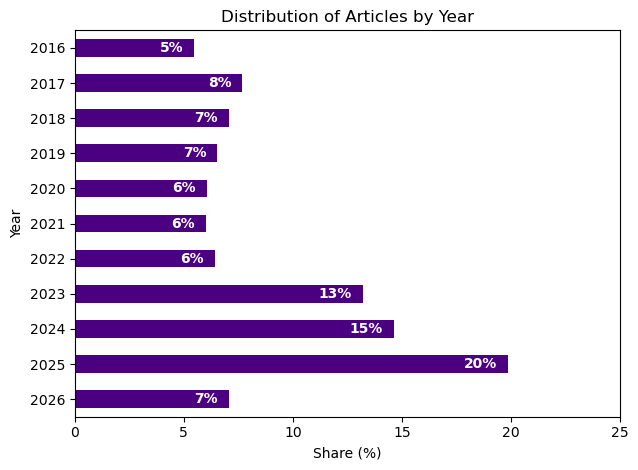

In [ ]:
# Distribution of Articles by Year


# plotting number of articles by year
df["webPublicationDate"] = pd.to_datetime(df["webPublicationDate"])
df["year"] = df["webPublicationDate"].dt.year
summary_year = df["year"].value_counts().sort_index(ascending=False).to_frame("Count")
summary_year["Share (%)"] = (
    summary_year["Count"] / summary_year["Count"].sum() * 100
).round(2)

plt.figure()
ax = summary_year["Share (%)"].plot(
    kind="barh",
    color="#4B0082",
)
plt.xlabel("Share (%)")
plt.ylabel("Year")
plt.title("Distribution of Articles by Year")

# data labels
for i, v in enumerate(summary_year["Share (%)"]):
    ax.text(
        v - 0.5,  # just inside the end of the bar
        i,
        f"{v:.0f}%",
        va="center",
        ha="right",
        color="white",
        fontweight="bold",
    )

plt.tight_layout()
ax.set_xlim(0, 25)
plt.show()

When reviewing this corpus, it is informative to pay special attention to the distribution of articles concerning "artificial intelligence" and "generative AI" by the year in which they were published. In the below plot, we observe that there was a steady mention of articles concerning these technologies between 2016-2022 before a sharp increase in 2023 through 2025. 

This spike in mentions of artificial intelligence was likely due to the November 30, 2022 release of an early demo of ChatGPT by OpenAI (Forbes, 2023). Mentions of artificial intelligence and generative AI remained steady in 2024 before again increasing in 2025. As these terms have become salient topics in modern discussions of the economy, labor, environment, and society it is reasonable to expect that the 2026 number of mentions will be close to or exceed recent years. 

# Topic Modeling

After executing initial descriptive analyses, topic modeling was performed to create dense clusters of articles which I then manually assigned with short topic labels. 



Once the articles were transformed and loaded into the DuckDB database, the “all-MiniLM-L6-v2” model was used to create embeddings from the text field that was constructed by concatenating the online title and cleaned body text of each article. This model was chosen because it is lightweight 
- Batch_size 64 (explain)
- In addition, the embeddings were normalized, which is a key step required for cosine similarity in Facebook AI Similarity Search (a tool that is used later in the pipeline for the RAG implementation). (UNDERSTAND WHY THIS IS)

These embeddings enable us to use BERTopic, which 

To build the topic model, I defined the following parameters: `UMAP`, `HDBSCAN`, `Vectorizer`, `KeyBERTInpsired`, and `nr_topics`.
- define what each of these is, and how I chose the specific option
- talk about dimensionality reduction.

I compared different configurations of the topic modeling parameters (see Appendix X.X for details). The final configuration chosen was one that reduced the share of uncategorized articles while identifying a reasonable number of topics. 

Results:
- X topics
- Top 10 topics by count






After an initial run of the best-performing BERTopic model, 8,705 uncategorized articles remained, representing approximately 35% of the total articles in the corpus. Upon closer review of the articles included in the "uncategorized" topic, I discovered many articles that referred to "AI" in their titles, suggesting that AI was mentioned among articles with diverse subject matter including education, labor, and art. 

To address the share of articles that were not initially clustered into a topic, I ran the BERT-based topic model for a second time on this subcorpus of articles. Since the model was being run on a smaller collection of uncategorized articles, I adjusted multiple parameters.
- Include mention of the parameters adjusted for running BERTopic on the subcorpus

This second stage of topic modeling results in X topics. Given the high count of total topics (117) after two stages of topic modeling, I halted the process at this stage before merging the two sets of topic assignments. Since topic modeling results in a name that includes a list of words central to each topic, I finished the process by manually labeling each topic and saving the new topic label assignments in DuckDB. 

In [ ]:
# topic table after merging and hand-labelling

- What initial patterns were observed
    - connect this to artificial intelligence
- Talk about the most prevalent topics and some of their member articles.

In [ ]:
# find median number of articles per topic
# make note of outliers
# count of topics with < 25 articles or fewer than 10 for example


Even after merging in the initially uncategorized articles, few topics emerged that had a clear connection to the concept of artificial intelligence. An initial conclusion may be that the BERTopic model struggled to differentiate between the mentions of artificial intelligence within the articles and their other diverse content. Upon closer inspection, the smaller topics did indeed cluster articles with similar content, with a few noticeable articles that were slightly different than their within-group peers. 

- Maori Tattoo Example
- Find one more example

It is possible that if certain parameters were adjusted (such as X, Y, or Z), then these exceptions would not be included within these topics and the topics would be more well-separated. Further topic modeling was not conducted because of its computational intensity and timeline constraints. In the future, adjustments could be made to the method of topic modeling used on the corpus to balance the inherent tradeoff between coverage and topic count. 

## Demonstration of Topic Search Functionality

# Named Entity Recognition

## Demonstration of Entity Search Functionality

# RAG Implementation

## Demonstration of Question & Answer Functionality

# Conclusion

Overall, this prototype was successful in establishing an ETL pipeline that extracted articles from The Guardian, cleaned them and loaded them into a queryable DuckDB database, and performed natural language processing techniques (topic modelling, named entity recognition, and retrieval augmented generation) to support the analysis of this corpus by diverse audiences. This prototype falls short in multiple ways (detailed below), but provides a starting point for similar analyses of news-related corpora and the development of open source applications for analyzing text as data. 

### Limitations and Future Work
The major obstacles encountered during the development of this prototype were timeline constraints and limited financial resources.

Due to limited time to iterate on the three methodological approaches (topic modeling, NER, and RAG) unsupervised machine learning approaches were chosen. It is possible that hand-labelling both positive and negative examples of topics and entities before training these models would have resulted in better performance. In addition, a limited set of four search terms were chosen to develop this corpus of articles that mentioned artificial intelligence. In the future, different sets of search terms could be tested and this prototype could be expanded to a broader set of concepts or an entirely different focus. 

One major limitation of this project was the lack of modularity introduced by generating the embeddings through the `all-MiniLM-L6-v2` in the `embed.py` script. It is possible that by testing different embeddings a better performing sentence embedding model could have been chosen. Once these embeddings were created, they were used for all downstream steps, including the named entity recognition and the creation of the FAISS index utilized for the RAG responses. 

There are multiple ways in which this work could be extended in the future. First, the current ETL pipeline is not live, but relies on a manual trigger to pull articles from The Guardian API and load them into the DuckDB instance. In the future, this could be live or triggered weekly or monthly to track trends in The Guardian's coverage of topics related to artificial intelligence. 

Due to timeline constraints, this app was designed to be deployed through Streamlit using localhost. The app could also be deployed for public use via AWS or a similar cloud provider. This would require potentially non-trivial costs due to the requirements to host the corpus and two LLMs in the cloud. A simple structure could involve uploading the articles directly into a S3 bucket, organizing them in a relational database through AWS Redshift or Amazon RDS, then setting up a series of step or AWS Lambda functions to perform each part of the NLP pipeline. An additional (and potentially simpler) infrastructure step could be to Dockerize this repository and upload the image to Amazon Elastic Container Service to run the Streamlit app through AWS Apprunner. 

Finally, alternative models or analytical methods could be implemented at each step of the analysis to provide comparisons to the methods presented above. Latent Dirichlet Allocation, a commonly used topic modeling technique, could be ran to compare to the BERT-based approach. Many different permutations of the spaCy NER and BERT NER models could be tested with different configurations of their parameters to identify the best-performing model to extract entities from the articles within the corpus. This prototype was developed to run with two local large language models (Ollama 3.2 3B and Mistral 7B). In the future, the app could employ additional open source model or state-of-the-art models available through the purchase of tokens such as Claude, ChatGPT, and Gemini. 

# Bibliography

# Appendix

## Topic Model Comparison Results

## Top Entities

